In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('datasets_ml/data_featured.csv')
df.columns

Index(['Url', 'Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes', 'LogPrice'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Url                   6288 non-null   object 
 1   Brand                 6288 non-null   object 
 2   Model                 6288 non-null   object 
 3   Limited               6288 non-null   object 
 4   CaseMaterialGrouped   6288 non-null   object 
 5   Glass                 6288 non-null   object 
 6   Case Shape            6288 non-null   object 
 7   CaseDiameterGrouped   6288 non-null   object 
 8   WaterResistanceLevel  6288 non-null   object 
 9   DialColorGrouped      6288 non-null   object 
 10  DialHandsGrouped      6288 non-null   object 
 11  Dial Indexes          6288 non-null   object 
 12  LogPrice              5132 non-null   float64
dtypes: float64(1), object(12)
memory usage: 638.8+ KB


In [4]:
cat_columns = ['Brand', 'Model', 'Limited', 'CaseMaterialGrouped', 'Glass',
       'Case Shape', 'CaseDiameterGrouped', 'WaterResistanceLevel',
       'DialColorGrouped', 'DialHandsGrouped', 'Dial Indexes']

df[cat_columns] = df[cat_columns].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6288 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Url                   6288 non-null   object  
 1   Brand                 6288 non-null   category
 2   Model                 6288 non-null   category
 3   Limited               6288 non-null   category
 4   CaseMaterialGrouped   6288 non-null   category
 5   Glass                 6288 non-null   category
 6   Case Shape            6288 non-null   category
 7   CaseDiameterGrouped   6288 non-null   category
 8   WaterResistanceLevel  6288 non-null   category
 9   DialColorGrouped      6288 non-null   category
 10  DialHandsGrouped      6288 non-null   category
 11  Dial Indexes          6288 non-null   category
 12  LogPrice              5132 non-null   float64 
dtypes: category(11), float64(1), object(1)
memory usage: 184.5+ KB


In [5]:
df = df[df['LogPrice'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5132 entries, 0 to 6287
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Url                   5132 non-null   object  
 1   Brand                 5132 non-null   category
 2   Model                 5132 non-null   category
 3   Limited               5132 non-null   category
 4   CaseMaterialGrouped   5132 non-null   category
 5   Glass                 5132 non-null   category
 6   Case Shape            5132 non-null   category
 7   CaseDiameterGrouped   5132 non-null   category
 8   WaterResistanceLevel  5132 non-null   category
 9   DialColorGrouped      5132 non-null   category
 10  DialHandsGrouped      5132 non-null   category
 11  Dial Indexes          5132 non-null   category
 12  LogPrice              5132 non-null   float64 
dtypes: category(11), float64(1), object(1)
memory usage: 192.9+ KB


In [6]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

In [7]:
X = df.drop(columns=['Url', 'LogPrice'])
y = df['LogPrice']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2222, random_state=42)

print("Số mẫu: Train:", X_train.shape[0], "| Validation:", X_val.shape[0], "| Test:", X_test.shape[0])

Số mẫu: Train: 3591 | Validation: 1027 | Test: 514


In [8]:
def evaluate_performance(y_true, y_pred, phase=""):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    # accuracy = 100 - mape

    print(f"{phase} Performance Evaluation:")
    print(f"R2: {r2:.4f} \t| RMSE: {rmse:.4f} \t| MAE: {mae:.4f}")

    # return r2, rmse, mae, mape, accuracy

In [9]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    cat_features=cat_columns,
    verbose=0
)

model.fit(
    X_train, y_train, 
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False,
    verbose=200  
)

y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

evaluate_performance(y_val, y_val_pred, phase="Val")
evaluate_performance(y_test, y_test_pred, phase="Test")

0:	learn: 1.0184551	test: 1.0108738	best: 1.0108738 (0)	total: 158ms	remaining: 2m 38s
200:	learn: 0.3741855	test: 0.4161344	best: 0.4161344 (200)	total: 4.67s	remaining: 18.6s
400:	learn: 0.3298072	test: 0.4032840	best: 0.4032840 (400)	total: 9.37s	remaining: 14s
600:	learn: 0.3000385	test: 0.3990572	best: 0.3990572 (600)	total: 14.1s	remaining: 9.33s
800:	learn: 0.2770539	test: 0.3985539	best: 0.3984824 (782)	total: 19.4s	remaining: 4.81s
999:	learn: 0.2597767	test: 0.3999013	best: 0.3983884 (828)	total: 24.4s	remaining: 0us

bestTest = 0.3983884406
bestIteration = 828

Shrink model to first 829 iterations.
Val Performance Evaluation:
R2: 0.8652 	| RMSE: 0.3984 	| MAE: 0.2779
Test Performance Evaluation:
R2: 0.8556 	| RMSE: 0.3988 	| MAE: 0.2865


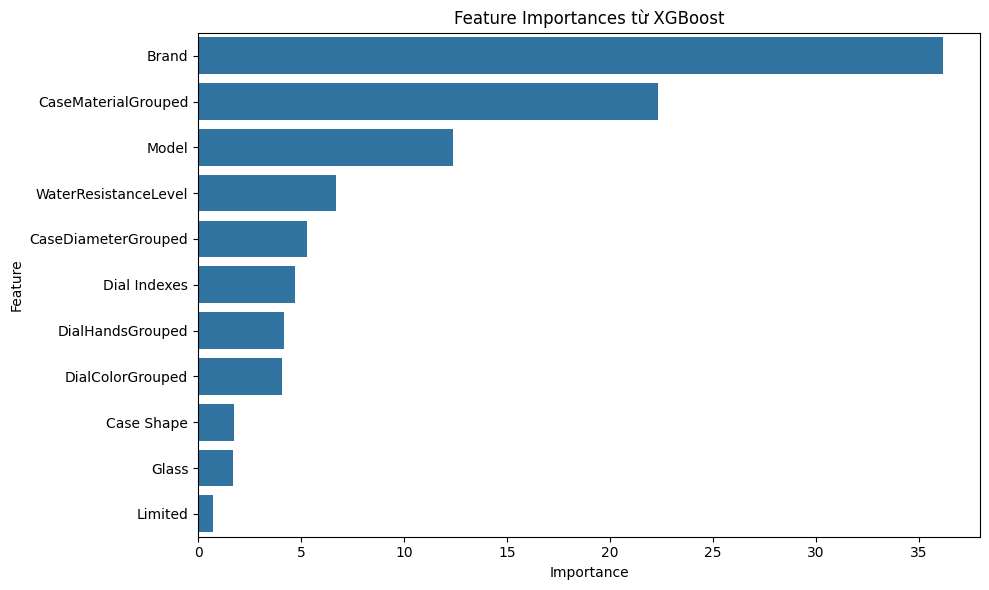

In [10]:
importances = model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances từ XGBoost")
plt.tight_layout()
plt.grid(False)
plt.show()

In [11]:
_, X_demo, _, y_demo = train_test_split(df.drop(columns=['LogPrice']), df['LogPrice'], test_size=0.2, random_state=42)

idx = 0
sample = X_demo.iloc[[idx]]

from catboost import Pool

sample_pool = Pool(data=sample.drop(columns=['Url']), cat_features=cat_columns)
log_price_pred = model.predict(sample_pool)

import numpy as np
price_pred = np.exp(log_price_pred)

print(sample['Url'].values[0])
print(f"Giá gốc: {np.exp(y_demo.iloc[idx]):.4f}")
print(f"Dự đoán: {price_pred[0]:.2f}")


https://watchbase.com/rolex/datejust-31/278275-0033
Giá gốc: 31101.0000
Dự đoán: 31721.33


In [12]:
from sklearn.model_selection import GridSearchCV

cb_model =CatBoostRegressor(
    random_state=42, 
    loss_function='RMSE', 
    verbose=False, 
    cat_features=cat_columns)

param_grid = {
    'iterations': [500, 700, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=cb_model, 
    param_grid=param_grid,
    scoring='r2', 
    cv=3, 
    n_jobs=-1, 
    verbose=False
)

grid.fit(X_train, y_train)

print(f'Best Parameters: {grid.best_params_}')
print(f'Best R2 Score: {grid.best_score_:.4f}')

Best Parameters: {'depth': 6, 'iterations': 1000, 'learning_rate': 0.05}
Best R2 Score: 0.8612


In [13]:
best_cb = grid.best_estimator_

best_cb.fit(X_train, y_train)

y_val_pred = best_cb.predict(X_val)
evaluate_performance(y_val, y_val_pred, phase="Stacking Validate with Tuned CB")
y_test_pred = best_cb.predict(X_test)
evaluate_performance(y_test, y_test_pred, phase="Stacking Test with Tuned CB")

Stacking Validate with Tuned CB Performance Evaluation:
R2: 0.8613 	| RMSE: 0.4040 	| MAE: 0.2858
Stacking Test with Tuned CB Performance Evaluation:
R2: 0.8567 	| RMSE: 0.3973 	| MAE: 0.2905


In [14]:
_, X_demo, _, y_demo = train_test_split(df.drop(columns=['LogPrice']), df['LogPrice'], test_size=0.2, random_state=42)

idx = 0
sample = X_demo.iloc[[idx]]

from catboost import Pool

sample_pool = Pool(data=sample.drop(columns=['Url']), cat_features=cat_columns)
log_price_pred = best_cb.predict(sample_pool)

import numpy as np
price_pred = np.exp(log_price_pred)

print(sample['Url'].values[0])
print(f"Giá gốc: {np.exp(y_demo.iloc[idx]):.4f}")
print(f"Dự đoán: {price_pred[0]:.2f}")

https://watchbase.com/rolex/datejust-31/278275-0033
Giá gốc: 31101.0000
Dự đoán: 33292.55


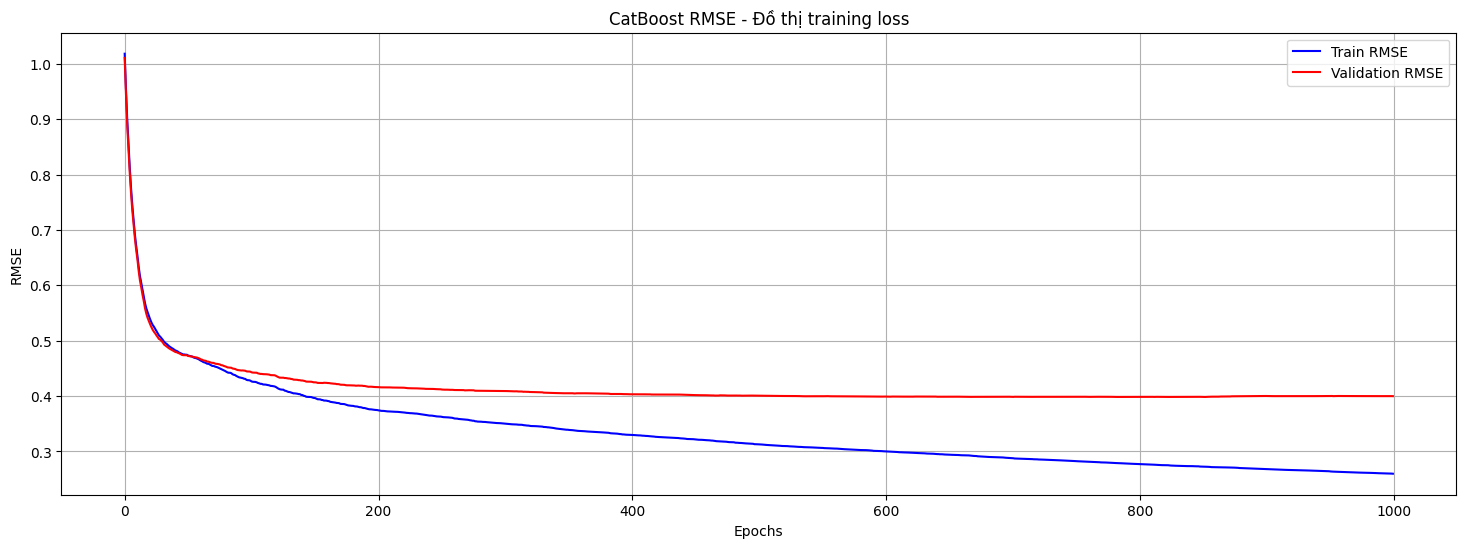

In [15]:
train_loss = model.get_evals_result()['learn']['RMSE'] if 'learn' in model.get_evals_result() else []
val_loss = model.get_evals_result()['validation']['RMSE'] if 'validation' in model.get_evals_result() else []

plt.figure(figsize=(18, 6))
epochs = len(train_loss)
x_axis = range(0, epochs)

plt.plot(x_axis, train_loss, 'b-', label='Train RMSE')
plt.plot(x_axis, val_loss, 'r-', label='Validation RMSE')

plt.title('CatBoost RMSE - Đồ thị training loss')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

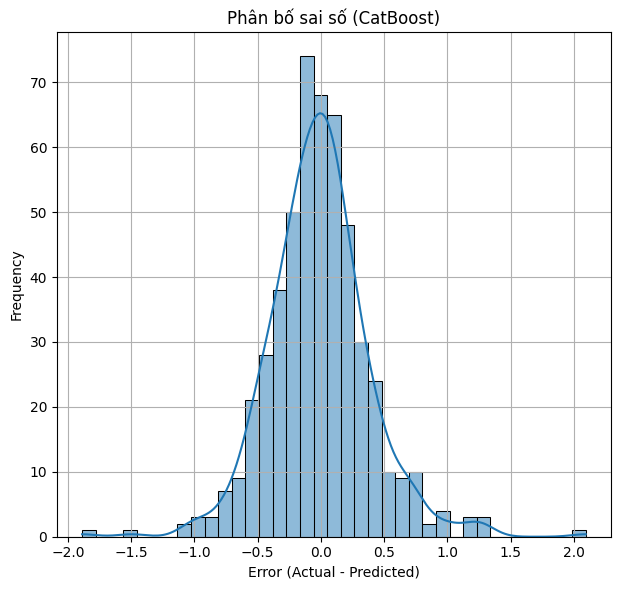

In [16]:
y_test_pred = best_cb.predict(X_test)
errors = y_test - y_test_pred

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(errors, kde=True)
plt.title('Phân bố sai số (CatBoost)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

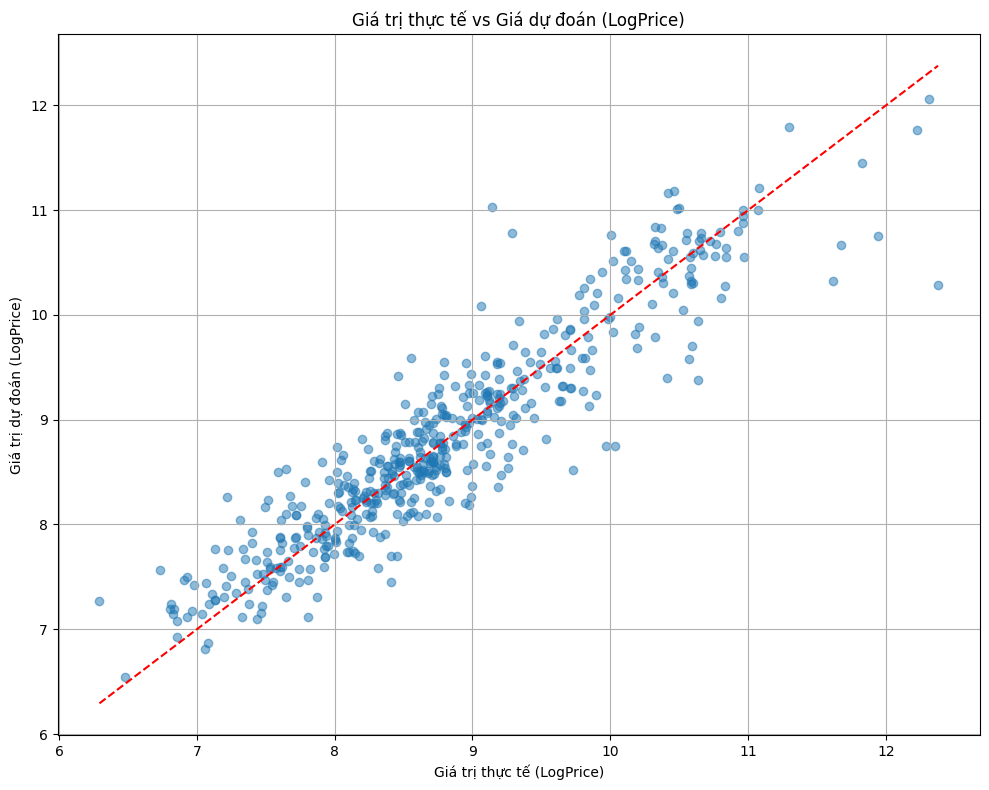

In [17]:
plt.figure(figsize=(10, 8))

plt.scatter(y_test, y_test_pred, alpha=0.5)

max_val = max(max(y_test), max(y_test_pred))
min_val = min(min(y_test), min(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.title('Giá trị thực tế vs Giá dự đoán (LogPrice)')
plt.xlabel('Giá trị thực tế (LogPrice)')
plt.ylabel('Giá trị dự đoán (LogPrice)')
plt.grid(True)
plt.tight_layout()
plt.show()

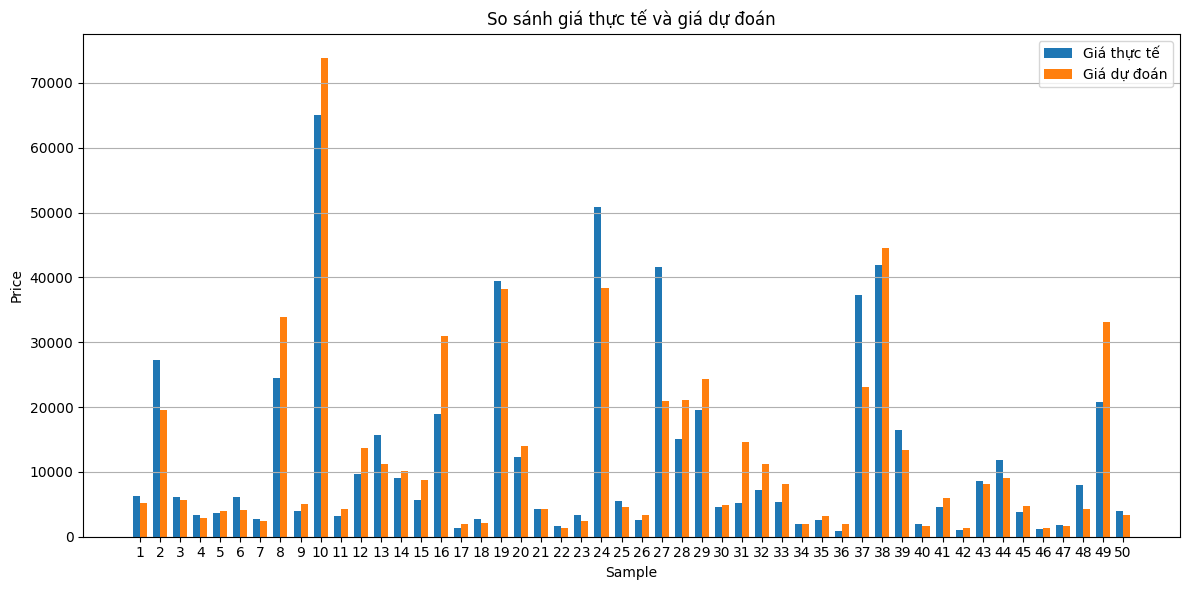

In [18]:
sample_indices = np.random.choice(range(len(y_test)), size=50, replace=False)

actual_prices = np.exp(y_test.iloc[sample_indices])
predicted_prices = np.exp(y_test_pred[sample_indices])

results_df = pd.DataFrame({
    'Sample': range(1, 51),
    'Actual Price': actual_prices.values,
    'Predicted Price': predicted_prices
})

plt.figure(figsize=(12, 6))

x = np.arange(len(sample_indices))  
width = 0.35  

plt.bar(x - width/2, results_df['Actual Price'], width, label='Giá thực tế')
plt.bar(x + width/2, results_df['Predicted Price'], width, label='Giá dự đoán')

plt.xlabel('Sample')
plt.ylabel('Price')
plt.title('So sánh giá thực tế và giá dự đoán')
plt.xticks(x, results_df['Sample'])
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [19]:
# Fix for training metrics if they're not available
if not train_loss or len(train_loss) == 0:
    print("Training loss not available, retraining model with explicit evaluation logging...")
    
    # Explicitly retrain with logging
    model = CatBoostRegressor(
        iterations=500,  # Reduced for speed
        learning_rate=0.1,
        depth=6,
        loss_function='RMSE',
        cat_features=cat_columns,
        verbose=0
    )
    
    model.fit(
        X_train, y_train, 
        eval_set=(X_val, y_val),
        use_best_model=True,
        verbose=False
    )
    
    # Get evaluation results
    evals_result = model.get_evals_result()
    
    if 'learn' in evals_result:
        train_loss = evals_result['learn']['RMSE']
        val_loss = evals_result['validation']['RMSE']
        
        print(f"Successfully retrieved training metrics: {len(train_loss)} epochs")
        
        # Plot the training metrics
        plt.figure(figsize=(10, 6))
        epochs = len(train_loss)
        x_axis = range(0, epochs)

        plt.plot(x_axis, train_loss, 'b-', label='Train RMSE')
        plt.plot(x_axis, val_loss, 'r-', label='Validation RMSE')

        plt.title('CatBoost RMSE - Training Progress')
        plt.xlabel('Epochs')
        plt.ylabel('RMSE')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Still could not retrieve training metrics. Check CatBoost version or other settings.")
        print("Available keys in evals_result:", evals_result.keys() if evals_result else "None")
